In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from qseg import *
import cv2
from my_segmentation import *
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, recall_score, precision_score
import time
import copy
import pandas as pd
from itertools import product

In [2]:
# load new images
path = "datasets/spheroidite_particles/"
image_files = [f for f in os.listdir(path+"image_patches/")]
mask_files = [f for f in os.listdir(path+"label_patches/")]

images = [cv2.imread(path+"image_patches/"+f, cv2.IMREAD_GRAYSCALE) for f in image_files]
masks = [cv2.imread(path+"label_patches/"+f, cv2.IMREAD_GRAYSCALE) for f in mask_files]

In [3]:
# test run
i = 0
sample = sharpnening(images[i])
dim = sample.shape[0]

# image to graph
start = time.time()
G = qseg_graph_construction(sample, normalized=False)

bqm, sampleset = annealer_solver_sa(G)
sampleset_first = sampleset.first.sample
end = time.time()
runtime = round(end - start, 3)

accuracy, iou, precision, recall, f1 = qseg_evaluation(sampleset_first, dim, masks[i])
print(runtime, accuracy, iou, f1, precision, recall)


31.637 0.472 0.166 0.221 0.635 0.508


In [5]:
results = []

for i in range(len(images)):
    sample = sharpnening(images[i])
    dim = sample.shape[0]

    start = time.time()
    # image to graph
    G = qseg_graph_construction(sample, normalized=False)

    bqm, sampleset = annealer_solver_sa(G)
    sampleset_first = sampleset.first.sample
    end = time.time()
    
    accuracy, iou, precision, recall, f1 = qseg_evaluation(sampleset_first, dim, masks[i])
    
    results.append({
        'Accuracy': accuracy,
        'IoU': iou,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Runtime': round(end - start, 3)
    })

df = pd.DataFrame(results)
df

,Accuracy,IoU,Precision,Recall,F1,Runtime
0,0.557,0.196,0.642,0.540,0.247,33.698
1,0.523,0.185,0.636,0.530,0.238,31.821
2,0.470,0.171,0.624,0.518,0.226,31.180
3,0.511,0.186,0.634,0.531,0.239,31.975
4,0.507,0.182,0.630,0.529,0.236,31.103
5,0.450,0.160,0.629,0.504,0.216,32.974
6,0.564,0.199,0.639,0.544,0.250,32.771
7,0.616,0.218,0.641,0.563,0.263,32.477
8,0.433,0.157,0.615,0.505,0.213,32.191
9,0.521,0.189,0.623,0.540,0.241,33.438


In [6]:
df.to_csv('spherodite_qseg.csv', index=False)

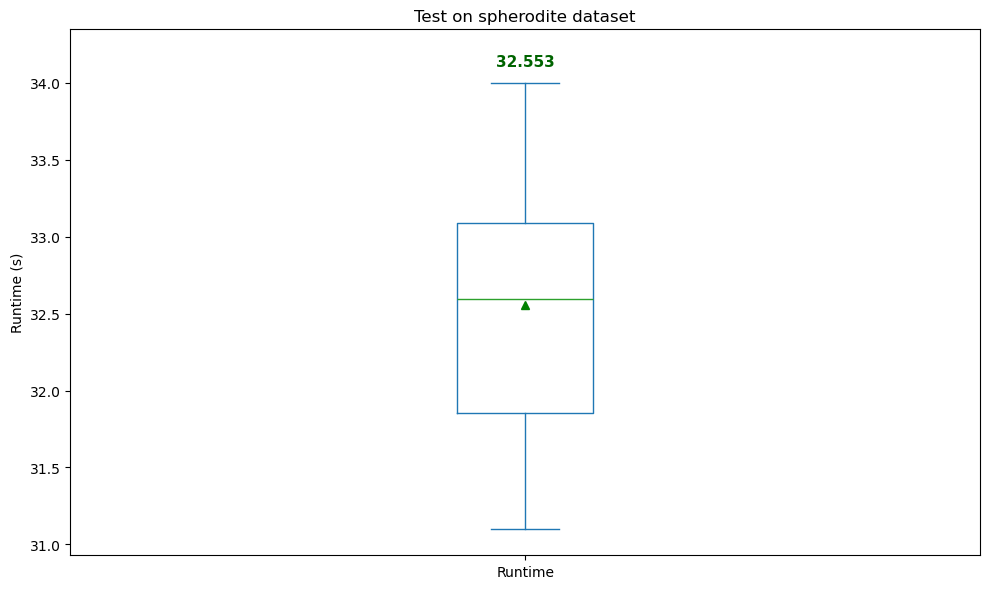

In [8]:
if 'idx' in df.columns:
    df = df.set_index('idx')

df_runtime = df[['Runtime']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

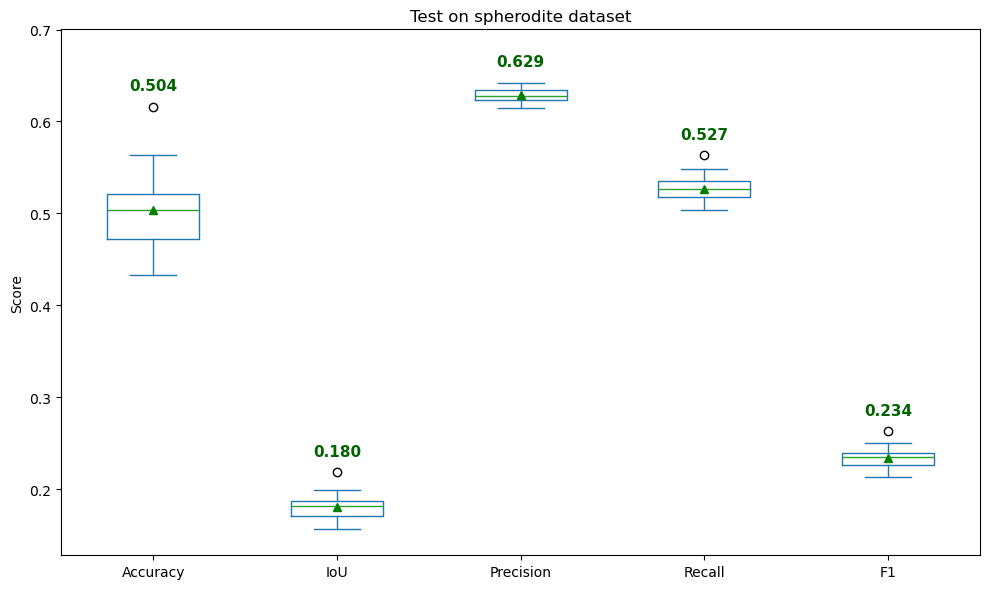

In [9]:
df.drop(columns=['Runtime'], inplace=True)

# 1. Generate boxplot with mean markers
ax = df.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df.values.max() - df.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df.columns, start=1):
    mean_val = df[col].mean()
    max_val = df[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df.values.min() - y_offset * 2, df.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

Node sampling + Q-Seg

In [ ]:
# test run
i = 0
sample = sharpnening(images[i])
dim = sample.shape[0]

# image to graph
start = time.time()
G = qseg_graph_construction(sample, normalized=False)

bqm, sampleset = annealer_solver_sa(G)
sampleset_first = sampleset.first.sample
end = time.time()
runtime = round(end - start, 3)

accuracy, iou, precision, recall, f1 = qseg_evaluation(sampleset_first, dim, masks[i])
print(runtime, accuracy, iou, f1, precision, recall)

In [9]:
len(sampleset_first.values())

8296

In [3]:
df_params = pd.read_csv('spherodite_this_work.csv')
l_th = df_params['thresholds'].tolist()
l_k = df_params['k'].tolist()

samplied_results = []

for i in range(len(images)):
    sample = sharpnening(images[i])
    dim = sample.shape[0]

    start = time.time()
    # image to graph
    G = qseg_graph_construction(sample, normalized=False)
    
    H, I, important, redundant = importance_sampling(G, threshold=l_th[i], node_size=0.1, show_graph=False)
    sampled_nodes = random_sampling(I, copy.deepcopy(redundant), k=l_k[i], seed=0)
    I.add_nodes_from(sampled_nodes)
    I = update_edgeweights_qseg(I, sample)
    
    bqm, sampleset = annealer_solver_sa(I)
    sampleset_first = sampleset.first.sample
    end = time.time()
    
    metrics_df = label_propagation_graph(I, sampleset_first, dim, masks[i])

    samplied_results.append({
        'Accuracy': metrics_df['accuracy'].iloc[0],
        'IoU': metrics_df['iou'].iloc[0],
        'Precision': metrics_df['precision'].iloc[0],
        'Recall': metrics_df['recall'].iloc[0],
        'F1': metrics_df['f1'].iloc[0],
        'runtime': round(end-start, 3),
    })
        
    df_results = pd.DataFrame(samplied_results)
    best_config = df_results.sort_values(by='IoU', ascending=False).iloc[0]

df_sampled = pd.DataFrame(samplied_results)
df_sampled

,Accuracy,IoU,Precision,Recall,F1,runtime
0,0.808,0.476,0.568,0.602,0.576,10.933
1,0.792,0.477,0.576,0.613,0.586,12.421
2,0.788,0.496,0.608,0.624,0.614,14.109
3,0.759,0.464,0.575,0.603,0.582,15.707
4,0.786,0.486,0.593,0.618,0.601,13.748
5,0.827,0.508,0.607,0.623,0.614,10.909
6,0.851,0.516,0.615,0.615,0.615,7.489
7,0.821,0.497,0.591,0.621,0.602,9.559
8,0.779,0.469,0.581,0.578,0.579,11.340
9,0.770,0.474,0.588,0.597,0.592,12.843


In [4]:
df_sampled.to_csv('spherodite_qseg_sampled.csv', index=False)

In [10]:
df_sampled = df_sampled.rename(columns={'runtime':'Runtime'})

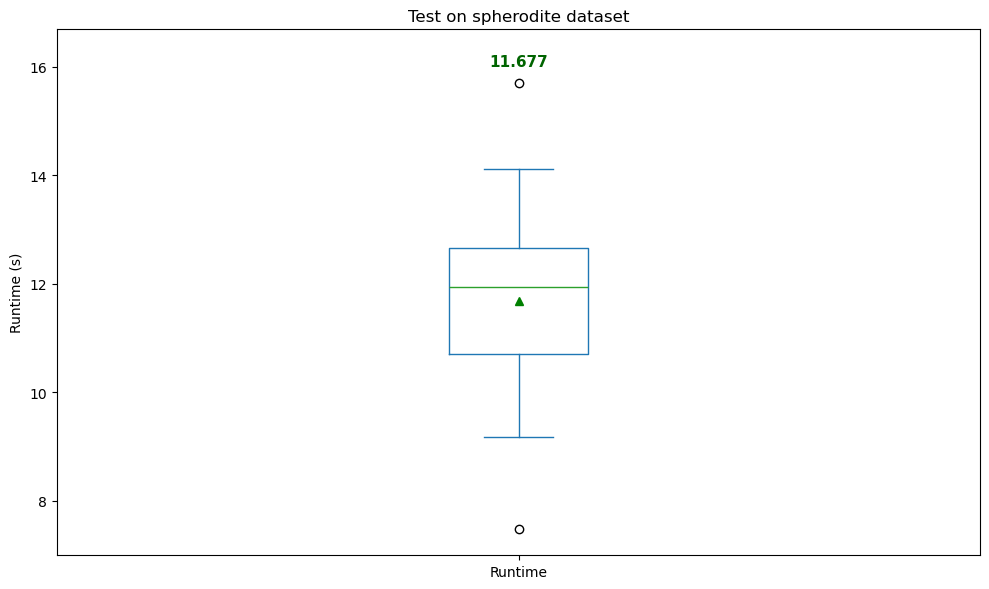

In [11]:
if 'idx' in df_sampled.columns:
    df_runtime = df_sampled.set_index('idx')

df_runtime = df_sampled[['Runtime']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

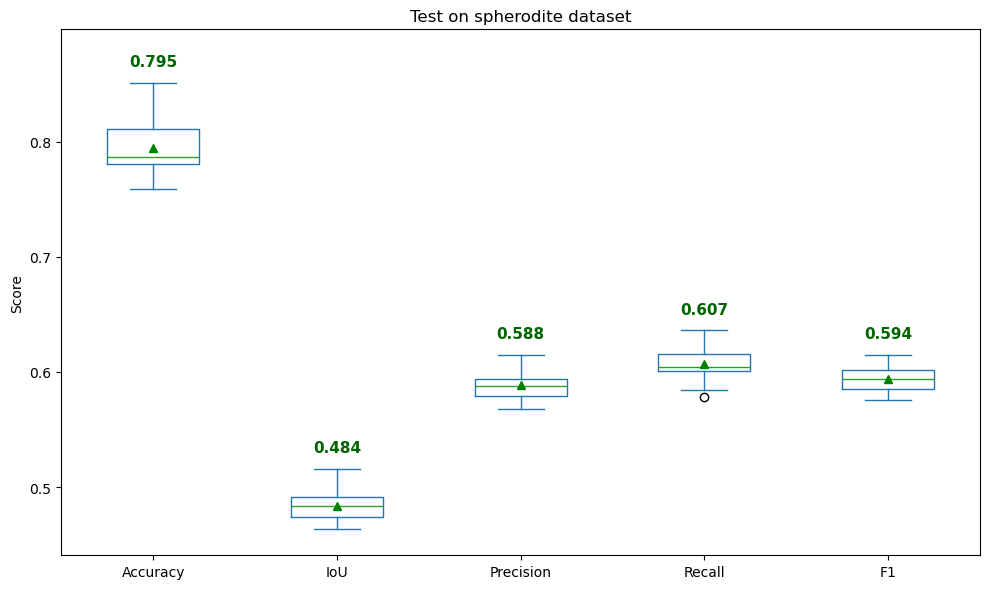

In [12]:
df_sampled.drop(columns=['Runtime'], inplace=True)

# 1. Generate boxplot with mean markers
ax = df_sampled.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_sampled.values.max() - df_sampled.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_sampled.columns, start=1):
    mean_val = df_sampled[col].mean()
    max_val = df_sampled[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_sampled.values.min() - y_offset * 2, df_sampled.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()